#Blood Cancer - Image Dataset
This dataset contains 10,000 single-cell images (64x64 pixels) taken from peripheral blood smears of patients diagnosed with Acute Myeloid Leukemia (Blood Cancer).



#Blood Cells Image Dataset

The dataset comprises 17,092 labeled images of normal peripheral blood cells, obtained using the CellaVision DM96 analyzer at the Hospital Clinic of Barcelona. It's organized into eight categories:

##Neutrophils:
Cells involved in the body's immune response to infection, characterized by multi-lobed nuclei and granulated cytoplasm.
##Eosinophils:
Cells implicated in allergic reactions and parasitic infections, recognizable by their bi-lobed nuclei and eosinophilic granules.
##Basophils:
Granulocytes with segmented nuclei and large, dark-staining cytoplasmic granules involved in allergic reactions and inflammation.
##Lymphocytes:
A diverse group of immune cells, including T cells, B cells, and natural killer cells, characterized by a large, round nucleus and minimal cytoplasm.
##Monocytes:
A type of white blood cell with a kidney-shaped nucleus and abundant cytoplasm, playing a role in immune response and inflammation.
##Immature Granulocytes:
Precursors to mature granulocytes, including promyelocytes, myelocytes, and metamyelocytes.
##Erythroblasts:
Immature red blood cells derived from bone marrow, characterized by a large nucleus and minimal cytoplasm.
##Platelets (Thrombocytes):
Small, disc-shaped cell fragments involved in blood clotting and wound healing.

In [ ]:

import os
import time
import shutil
import pathlib
import itertools
from PIL import Image
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras import regularizers
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"khizerz","key":"368425f97ed0eb641d279127a4df758d"}'}

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d akhiljethwa/blood-cancer-image-dataset
!kaggle datasets download -d unclesamulus/blood-cells-image-dataset

Dataset URL: https://www.kaggle.com/datasets/akhiljethwa/blood-cancer-image-dataset
License(s): CC-BY-SA-3.0
 83% 85.0M/102M [00:01<00:00, 96.6MB/s]
100% 102M/102M [00:01<00:00, 93.1MB/s] 
Dataset URL: https://www.kaggle.com/datasets/unclesamulus/blood-cells-image-dataset
License(s): CC-BY-SA-4.0
100% 268M/268M [00:02<00:00, 147MB/s]
100% 268M/268M [00:02<00:00, 104MB/s]


In [ ]:
!unzip blood-cancer-image-dataset.zip
!unzip blood-cells-image-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: bloodcells_dataset/neutrophil/BNE_448273.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_44875.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_448776.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_449730.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_449915.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_450464.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_451701.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_451729.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_453088.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_454089.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_454943.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_455080.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_4555.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_455636.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_45575.jpg  
  inflating: bloodcells_dataset/neutrophil/BNE_456543

In [ ]:

bloodcells_dataset_path = os.path.join(os.getcwd(), "bloodcells_dataset")

subdirectories = [os.path.join(bloodcells_dataset_path, d) for d in os.listdir(bloodcells_dataset_path) if os.path.isdir(os.path.join(bloodcells_dataset_path, d))]

for subdirectory in subdirectories:
    for filename in os.listdir(subdirectory):
        file_path = os.path.join(subdirectory, filename)
        new_file_path = os.path.join(bloodcells_dataset_path, filename)
        shutil.move(file_path, new_file_path)

    shutil.rmtree(subdirectory)


In [ ]:

blood_cancer_path = os.path.join("Blood_Cancer")
files = os.listdir(blood_cancer_path)

for i, filename in enumerate(files):
    new_filename = "cancer" + str(i + 1) + ".jpg"
    os.rename(os.path.join(blood_cancer_path, filename), os.path.join(blood_cancer_path, new_filename))


In [ ]:

bloodcells_dataset_path = os.path.join(os.getcwd(), "bloodcells_dataset")
files = os.listdir(bloodcells_dataset_path)

for i, filename in enumerate(files):
    new_filename = "non-cancer" + str(i + 1) + ".jpg"
    os.rename(os.path.join(bloodcells_dataset_path, filename), os.path.join(bloodcells_dataset_path, new_filename))


In [ ]:


blood_cancer_path = os.path.join("Blood_Cancer")
files = os.listdir(blood_cancer_path)

for filename in files:
    if filename.endswith(".tiff"):
        image_path = os.path.join(blood_cancer_path, filename)
        image = Image.open(image_path)
        new_filename = filename.replace(".tiff", ".jpg")
        new_image_path = os.path.join(blood_cancer_path, new_filename)
        image.save(new_image_path)


In [ ]:

blood_cancer_path = os.path.join(os.getcwd(), "Blood_Cancer")
bloodcells_dataset_path = os.path.join(os.getcwd(), "bloodcells_dataset")

merged_dataset_path = os.path.join(os.getcwd(), "merged_dataset")
os.mkdir(merged_dataset_path)


for filename in os.listdir(blood_cancer_path):
    shutil.copy(os.path.join(blood_cancer_path, filename), os.path.join(merged_dataset_path, filename))

for filename in os.listdir(bloodcells_dataset_path):
    shutil.copy(os.path.join(bloodcells_dataset_path, filename), os.path.join(merged_dataset_path, filename))

In [ ]:

import pandas as pd

merged_dataset_path = os.path.join(os.getcwd(), "merged_dataset")

data = []

for filename in os.listdir(merged_dataset_path):
    if filename.endswith(".jpg"):
        if filename.startswith("cancer"):
            label = "cancer"
        else:
            label = "non-cancer"

        file_path = os.path.join(merged_dataset_path, filename)

        data.append({"file_path": file_path, "label": label})




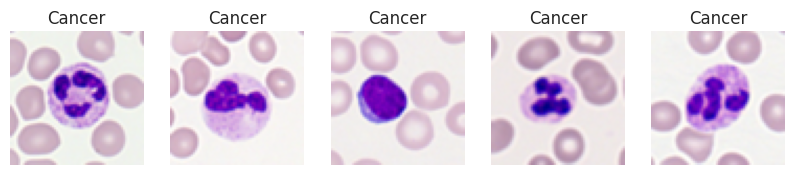

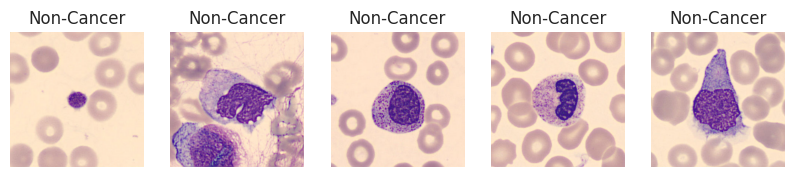

In [ ]:


import matplotlib.pyplot as plt
# Assuming 'data' is a list of dictionaries with 'file_path' and 'label' keys
cancer_images = [d['file_path'] for d in data if d['label'] == 'cancer']
non_cancer_images = [d['file_path'] for d in data if d['label'] == 'non-cancer']

# Display a few cancer images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = Image.open(cancer_images[i])
    plt.imshow(image)
    plt.title('Cancer')
    plt.axis('off')
plt.show()

# Display a few non-cancer images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = Image.open(non_cancer_images[i])
    plt.imshow(image)
    plt.title('Non-Cancer')
    plt.axis('off')
plt.show()


In [ ]:

df = pd.DataFrame(data)


In [ ]:
df.head(5)

,file_path,label
0,/content/merged_dataset/non-cancer4691.jpg,non-cancer
1,/content/merged_dataset/non-cancer6504.jpg,non-cancer
2,/content/merged_dataset/cancer3703.jpg,cancer
3,/content/merged_dataset/cancer1905.jpg,cancer
4,/content/merged_dataset/non-cancer4806.jpg,non-cancer


# Checking Class imbalance

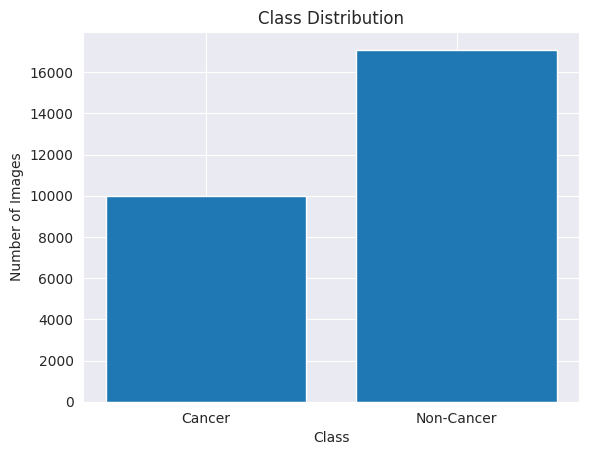

In [ ]:

cancer_count = df[df["label"] == "cancer"].shape[0]
non_cancer_count = df[df["label"] == "non-cancer"].shape[0]

plt.bar(["Cancer", "Non-Cancer"], [cancer_count, non_cancer_count])
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()


# Resizing Image to 64 X 64

In [ ]:

merged_dataset_path = os.path.join(os.getcwd(), "merged_dataset")


for filename in os.listdir(merged_dataset_path):

    if filename.endswith(".jpg"):

        file_path = os.path.join(merged_dataset_path, filename)


        image = cv2.imread(file_path)


        image = cv2.resize(image, (64, 64))

        cv2.imwrite(file_path, image)


In [ ]:

resized_dataset_path = os.path.join(os.getcwd(), "merged_dataset")
for filename in os.listdir(resized_dataset_path):

    if filename.endswith(".jpg"):

        file_path = os.path.join(resized_dataset_path, filename)

        image = cv2.imread(file_path)

        if image.shape[0] != 64 or image.shape[1] != 64:
            print(f"Image {filename} is not 64x64.")
        else:
            print(f"Image {filename} is 64x64.")


Streaming output truncated to the last 5000 lines.
Image non-cancer11716.jpg is 64x64.
Image cancer3335.jpg is 64x64.
Image cancer4479.jpg is 64x64.
Image non-cancer2126.jpg is 64x64.
Image cancer8473.jpg is 64x64.
Image non-cancer7390.jpg is 64x64.
Image cancer7827.jpg is 64x64.
Image cancer4138.jpg is 64x64.
Image cancer7412.jpg is 64x64.
Image non-cancer8143.jpg is 64x64.
Image non-cancer14783.jpg is 64x64.
Image non-cancer7323.jpg is 64x64.
Image cancer8187.jpg is 64x64.
Image non-cancer11223.jpg is 64x64.
Image non-cancer12911.jpg is 64x64.
Image non-cancer10424.jpg is 64x64.
Image non-cancer478.jpg is 64x64.
Image cancer4064.jpg is 64x64.
Image non-cancer3223.jpg is 64x64.
Image non-cancer7430.jpg is 64x64.
Image non-cancer6296.jpg is 64x64.
Image non-cancer4718.jpg is 64x64.
Image cancer438.jpg is 64x64.
Image non-cancer2973.jpg is 64x64.
Image cancer570.jpg is 64x64.
Image cancer8443.jpg is 64x64.
Image non-cancer2244.jpg is 64x64.
Image non-cancer79.jpg is 64x64.
Image cancer2

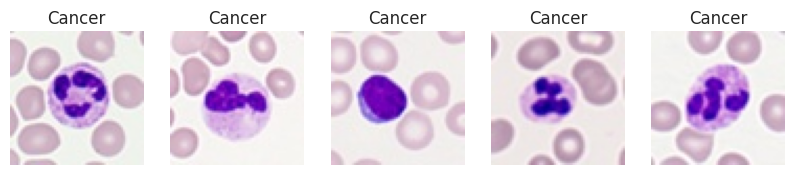

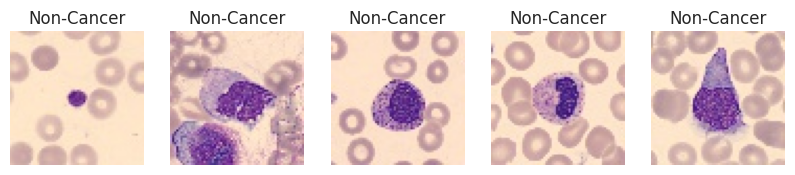

In [ ]:


import matplotlib.pyplot as plt
# Assuming 'data' is a list of dictionaries with 'file_path' and 'label' keys
cancer_images = [d['file_path'] for d in data if d['label'] == 'cancer']
non_cancer_images = [d['file_path'] for d in data if d['label'] == 'non-cancer']

# Display a few cancer images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = Image.open(cancer_images[i])
    plt.imshow(image)
    plt.title('Cancer')
    plt.axis('off')
plt.show()

# Display a few non-cancer images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = Image.open(non_cancer_images[i])
    plt.imshow(image)
    plt.title('Non-Cancer')
    plt.axis('off')
plt.show()


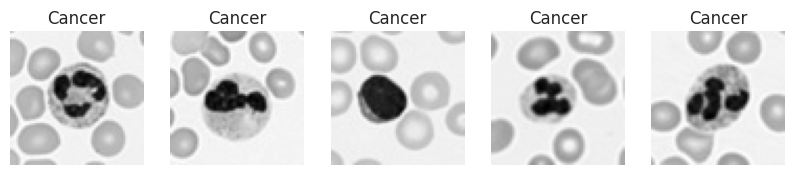

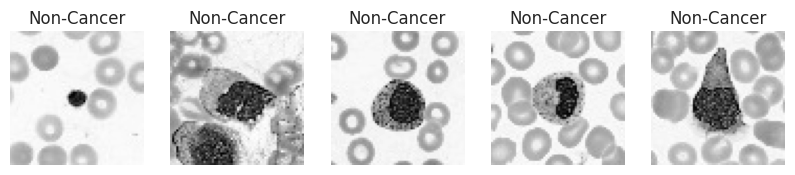

In [ ]:

import matplotlib.pyplot as plt
merged_dataset_path = os.path.join(os.getcwd(), "merged_dataset")

for filename in os.listdir(merged_dataset_path):
    if filename.endswith(".jpg"):
        file_path = os.path.join(merged_dataset_path, filename)
        img = cv2.imread(file_path)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        cv2.imwrite(file_path, img_gray)

# Assuming 'data' is a list of dictionaries with 'file_path' and 'label' keys
cancer_images = [d['file_path'] for d in data if d['label'] == 'cancer']
non_cancer_images = [d['file_path'] for d in data if d['label'] == 'non-cancer']

# Display a few cancer images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = Image.open(cancer_images[i])
    plt.imshow(image, cmap='gray')
    plt.title('Cancer')
    plt.axis('off')
plt.show()

# Display a few non-cancer images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    image = Image.open(non_cancer_images[i])
    plt.imshow(image, cmap='gray')
    plt.title('Non-Cancer')
    plt.axis('off')
plt.show()


In [ ]:
df.head(5)

,file_path,label
0,/content/merged_dataset/non-cancer4691.jpg,non-cancer
1,/content/merged_dataset/non-cancer6504.jpg,non-cancer
2,/content/merged_dataset/cancer3703.jpg,cancer
3,/content/merged_dataset/cancer1905.jpg,cancer
4,/content/merged_dataset/non-cancer4806.jpg,non-cancer


In [ ]:

merged_dataset_path = os.path.join(os.getcwd(), "merged_dataset")

for filename in os.listdir(merged_dataset_path):
    if filename.endswith(".jpg"):

        file_path = os.path.join(merged_dataset_path, filename)

        image = Image.open(file_path)

        image = image.convert("L")

        image.save(file_path)



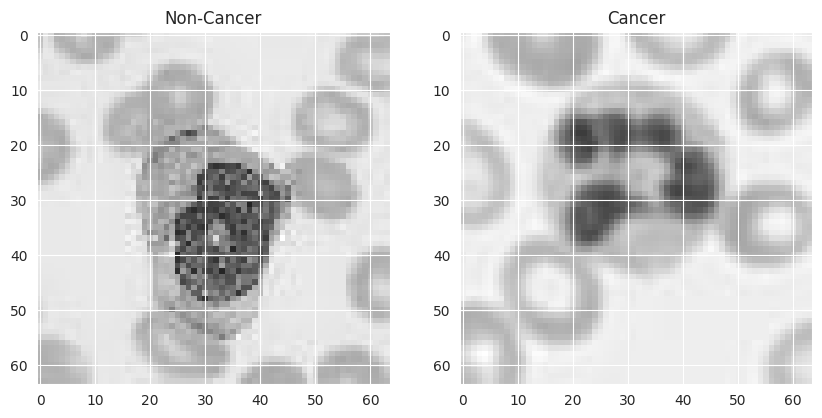

In [ ]:

image_non_cancer = cv2.imread(os.path.join(merged_dataset_path, "non-cancer1.jpg"))
image_cancer = cv2.imread(os.path.join(merged_dataset_path, "cancer1.jpg"))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_non_cancer)
plt.title("Non-Cancer")
plt.subplot(1, 2, 2)
plt.imshow(image_cancer)
plt.title("Cancer")
plt.show()

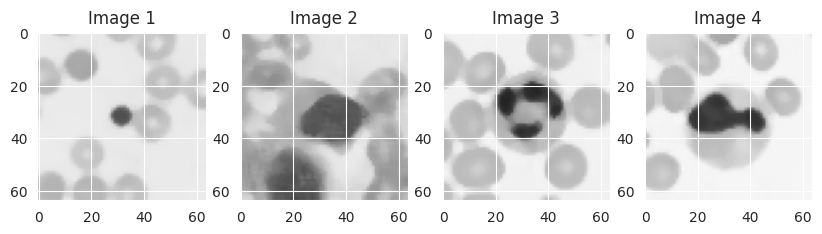

In [ ]:


import matplotlib.pyplot as plt
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def remove_noise(image):

  denoised_image = cv2.medianBlur(image, 5)
  return denoised_image


images_path = [os.path.join(merged_dataset_path, filename) for filename in os.listdir(merged_dataset_path) if filename.endswith(".jpg")]


denoised_images = []
for image_path in images_path:
  image = cv2.imread(image_path)
  denoised_image = remove_noise(image)
  denoised_images.append(denoised_image)

plt.figure(figsize=(10, 5))
for i in range(4):
  plt.subplot(1, 4, i+1)
  plt.imshow(denoised_images[i])
  plt.title(f"Image {i+1}")
plt.show()


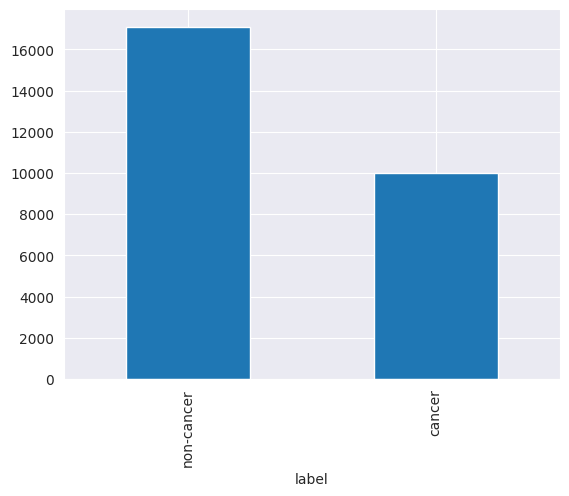

In [ ]:

import matplotlib.pyplot as plt
df["label"].value_counts().plot(kind="bar")
plt.show()


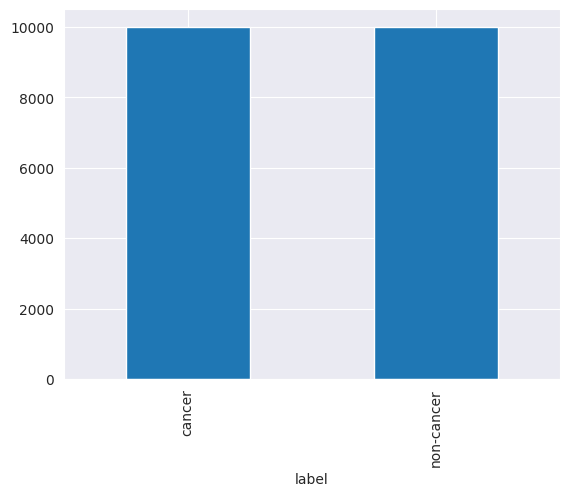

In [ ]:

df_cancer = df[df["label"] == "cancer"]
df_non_cancer = df[df["label"] == "non-cancer"].sample(n=len(df_cancer))
df_balanced = pd.concat([df_cancer, df_non_cancer]).reset_index(drop=True)

df_balanced["label"].value_counts().plot(kind="bar")
plt.show()


In [ ]:

df_balanced["label"] = df_balanced["label"].apply(lambda x: 0 if x == "non-cancer" else 1)


In [ ]:

image_paths = df_balanced["file_path"].tolist()
labels = df_balanced["label"].tolist()


train_paths, test_paths, train_labels, test_labels = train_test_split(image_paths, labels, test_size=0.2, random_state=42)


def load_image(image_path):
  image = cv2.imread(image_path)
  image = cv2.resize(image, (64, 64))
  image = image.astype("float32") / 255.0
  return image

train_images = [load_image(path) for path in train_paths]
test_images = [load_image(path) for path in test_paths]


train_images = np.array(train_images)
test_images = np.array(test_images)
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)


In [ ]:
# prompt: model = Sequential()
# model.add(Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(64, 64, 3)))
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
# model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Flatten())
# model.add(Dense(128, activation="relu"))
# model.add(Dense(1, activation="sigmoid"))
# model.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate==0.001), metrics=["accuracy"])
# model.summary()

# Assuming you have already defined the model as in your provided code
# ... (your model definition code) ...

# Assuming you have train_images, train_labels, test_images, test_labels defined
# ... (your data loading and preprocessing code) ...


history = model.fit(train_images, train_labels, epochs=10, batch_size=32, validation_data=(test_images, test_labels))


# Evaluate the model
loss, accuracy = model.evaluate(test_images, test_labels)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Plot the training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot the training and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# prompt: history = model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8525 - loss: 0.2468 - val_accuracy: 0.9987 - val_loss: 0.0031
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9963 - loss: 0.0194 - val_accuracy: 0.9983 - val_loss: 0.0048
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9968 - loss: 0.0099 - val_accuracy: 0.9990 - val_loss: 0.0027
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9990 - loss: 0.0021 - val_accuracy: 0.9990 - val_loss: 0.0027
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9987 - loss: 0.0044 - val_accuracy: 0.9983 - val_loss: 0.0050


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


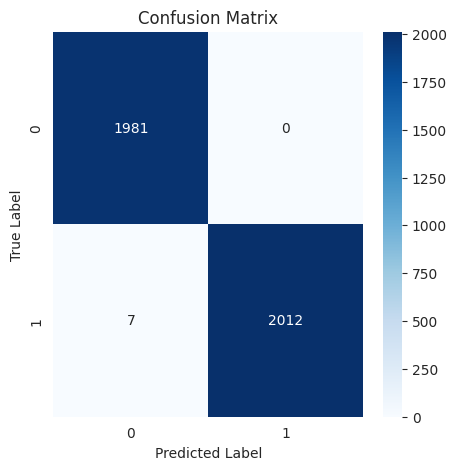

In [ ]:
# prompt: show  confusion matrix

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

y_pred = model.predict(test_images)
y_pred = np.round(y_pred)

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


The metrics indicate an excellent performance of the model with very high precision, recall, and F1 score, suggesting that the model makes very few errors in both false positives and false negatives.